In [1]:
import pandas as pd
import bambi as bmb
import arviz as az
import arviz_plots as azp

df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/red_spruce_2022.csv')
df.columns

Index(['inventory_year', 'survey_unit', 'county', 'plot_number', 'tree_number',
       'diameter', 'height', 'SPCD', 'log_height', 'log_diameter'],
      dtype='str')

To see if our hierarchical structure actually improves our predictions, let's fit a simple, 'naive' model. This baseline model completely ignores regional differences (counties) and assumes all trees follow one universal growth trend


In [2]:
model_formula = "log_height ~ log_diameter"

model = bmb.Model(model_formula, df)

In [4]:
results = model.fit(draws=2000, tune=2000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_diameter]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


In [5]:
az.summary(results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.222,0.009,0.206,0.238,0.0,0.000,12606.0,6157.0,1.0
Intercept,0.176,0.048,0.087,0.266,0.0,0.001,13742.0,6674.0,1.0
log_diameter,0.800,0.017,0.768,0.832,0.0,0.000,13973.0,6261.0,1.0


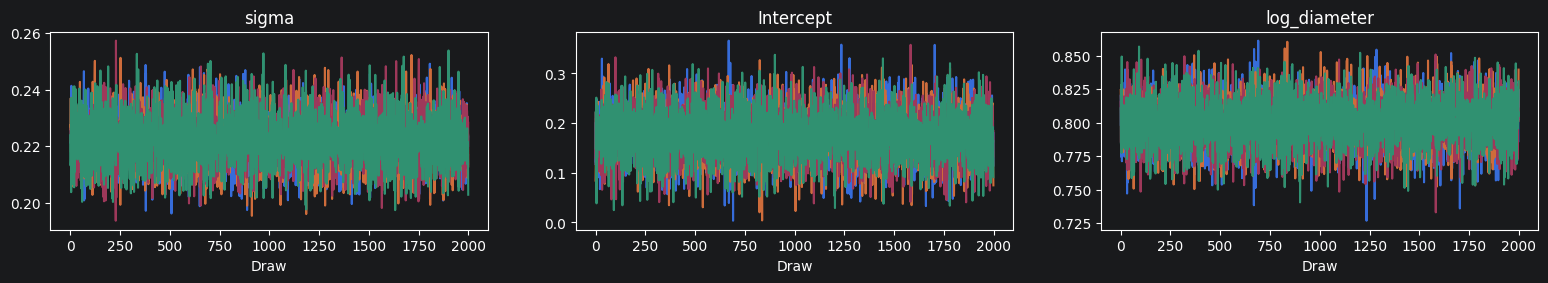

In [6]:
azp.plot_trace(results)

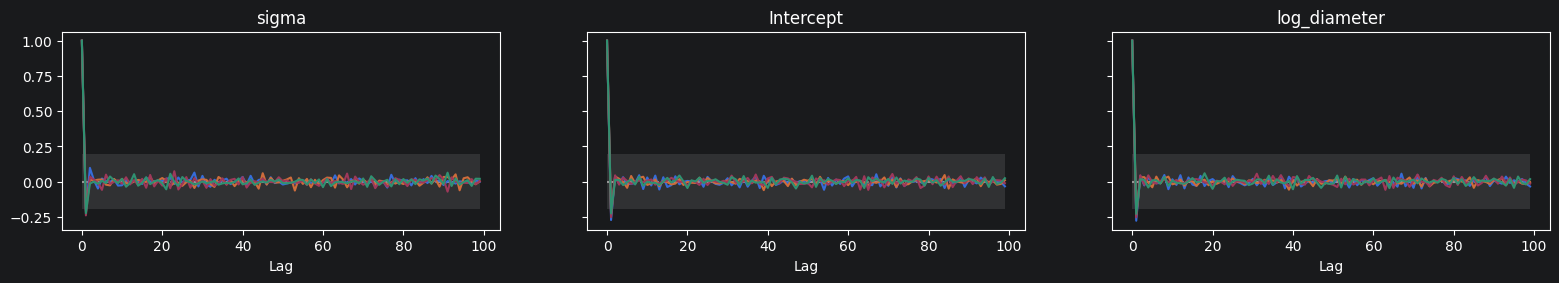

In [7]:
azp.plot_autocorr(results)

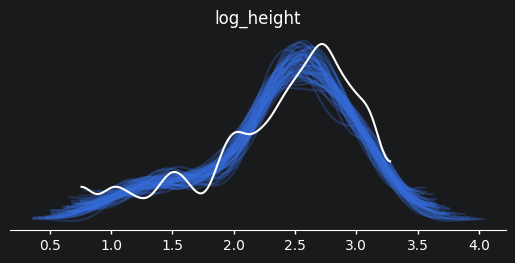

In [8]:
model.predict(results, kind="response")
azp.plot_ppc_dist(results)